# Tarea 3

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.linalg import eigh, cholesky
from scipy.stats import norm
import linearmodels.panel as lmp
from pylab import plot, show, axis, subplot, xlabel, ylabel, grid
import semopy 
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import PCA
from IPython.display import Image


%matplotlib inline

## 1. Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

In [42]:
df=pd.read_csv('../data/junaeb3.csv')
df.describe()

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
count,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,...,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,30051.000000,31055.000000,30682.000000,31055.000000,31055.000000
mean,0.538979,82.589084,1.017787,0.720335,0.966511,1.114088,1.391177,1.262856,1.256352,1.268588,...,1.333666,1.853743,1.385349,1.502785,1.694735,2.556620,0.911544,13.069291,12.955756,0.092803
std,0.498486,4.360270,1.370552,0.449415,0.189671,0.394004,0.650190,0.585766,0.578266,0.564929,...,0.666009,0.941171,0.668783,0.799375,0.984946,1.068041,0.283961,3.338320,3.425190,0.943509
min,0.000000,62.000000,-5.020000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-1.000000
25%,0.000000,80.000000,0.120000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,12.000000,11.000000,-1.000000
50%,1.000000,81.000000,0.970000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,13.000000,13.000000,0.000000
75%,1.000000,82.000000,1.930000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,2.000000,2.000000,2.000000,3.000000,1.000000,15.000000,14.000000,1.000000
max,1.000000,107.000000,5.040000,2.000000,2.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,22.000000,22.000000,1.000000


<Axes: >

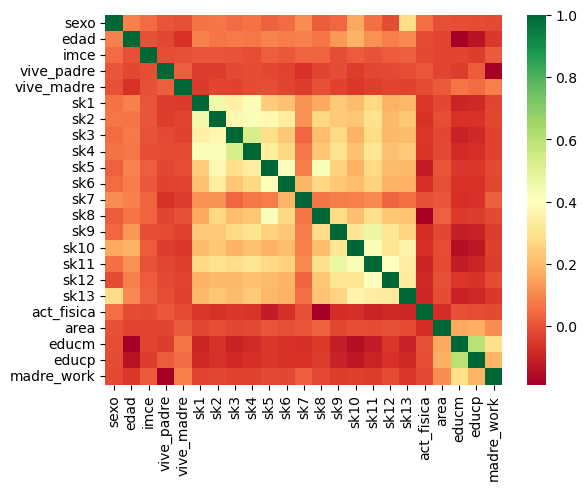

In [43]:
sns.heatmap(df.corr(), cmap='RdYlGn')

## 2. A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).

In [3]:
list_dsk = [f'sk{i+1}' for i in range(13)]
df1 = df[list_dsk]
df1

,sk1,sk2,sk3,sk4,sk5,sk6,sk7,sk8,sk9,sk10,sk11,sk12,sk13
0,1,1,1,2,1,2,2,1,2,2,2,3,2
1,1,1,1,1,1,1,4,1,1,1,1,1,1
2,2,2,3,2,1,2,3,2,2,3,2,1,3
3,1,1,1,1,1,1,2,1,1,1,1,1,1
4,1,1,1,1,1,1,3,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31050,1,3,1,2,2,1,1,3,2,2,2,1,1
31051,1,1,2,2,1,1,1,2,1,3,2,1,4
31052,1,1,1,1,1,1,1,1,1,3,1,1,1
31053,1,1,1,1,2,2,1,2,1,2,1,1,2


In [4]:
fa = FactorAnalyzer(rotation='varimax').fit(df1)

In [5]:
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
fa.loadings_

array([[0.183970, 0.549198, 0.155598],
       [0.177203, 0.517433, 0.350410],
       [0.182944, 0.596588, 0.168045],
       [0.198779, 0.686060, 0.200987],
       [0.121309, 0.219980, 0.724979],
       [0.173086, 0.210702, 0.481159],
       [0.069524, 0.074626, 0.136478],
       [0.269342, 0.104813, 0.478344],
       [0.495931, 0.215337, 0.207927],
       [0.563365, 0.122575, 0.127228],
       [0.664883, 0.209988, 0.205834],
       [0.526984, 0.116246, 0.144172],
       [0.485171, 0.154101, 0.134872]])

In [6]:
fa.get_eigenvalues()

(array([4.114952, 1.341624, 1.100575, 1.000161, 0.781977, 0.698537,
        0.695787, 0.684453, 0.604042, 0.523209, 0.512081, 0.487796,
        0.454807]),
 array([3.526388, 0.743955, 0.517426, 0.211290, 0.114533, 0.062767,
        0.008348, -0.008400, -0.035529, -0.060437, -0.080399, -0.084919,
        -0.127254]))

In [7]:
fa.get_communalities()

array([0.359674, 0.421925, 0.417625, 0.550587, 0.588702, 0.305868,
       0.029029, 0.312344, 0.335551, 0.348592, 0.528531, 0.312011,
       0.277328])

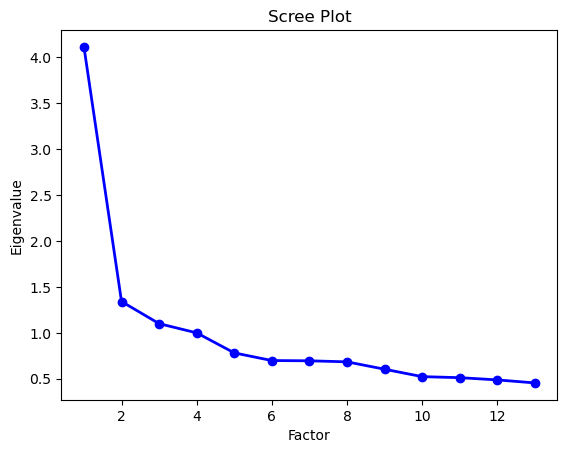

In [8]:
values = np.arange(1,14)
eigenvalues = pd.DataFrame(data=fa.get_eigenvalues())
plt.plot(values, eigenvalues.loc[0], 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.show()

In [9]:
fa.get_factor_variance()

(array([1.778781, 1.648043, 1.360946]),
 array([0.136829, 0.126773, 0.104688]),
 array([0.136829, 0.263602, 0.368290]))

In [10]:
print(semopy.efa.explore_cfa_model(df1, pval=0.01))

eta1 =~ sk11 + sk9 + sk10 + sk12 + sk13 + sk4
eta2 =~ sk7 + sk6
eta3 =~ sk4 + sk11 + sk2 + sk5 + sk3 + sk9 + sk1 + sk8 + sk6 + sk13



In [11]:
fa = FactorAnalyzer(n_factors=3, rotation='varimax')
fa.fit(df1)

FactorAnalyzer(rotation='varimax', rotation_kwargs={})

In [12]:
loadings = fa.loadings_

loading_df = pd.DataFrame(loadings, 
                          index=df1.columns, 
                          columns=[f'Factor_{i+1}' for i in range(loadings.shape[1])])
print(loading_df)

      Factor_1  Factor_2  Factor_3
sk1   0.183970  0.549198  0.155598
sk2   0.177203  0.517433  0.350410
sk3   0.182944  0.596588  0.168045
sk4   0.198779  0.686060  0.200987
sk5   0.121309  0.219980  0.724979
sk6   0.173086  0.210702  0.481159
sk7   0.069524  0.074626  0.136478
sk8   0.269342  0.104813  0.478344
sk9   0.495931  0.215337  0.207927
sk10  0.563365  0.122575  0.127228
sk11  0.664883  0.209988  0.205834
sk12  0.526984  0.116246  0.144172
sk13  0.485171  0.154101  0.134872


In [13]:
factores = fa.transform(df1)

In [14]:
loadings = fa.loadings_

#### Respuesta: El nº de factores óptimos es 3 dado el Scree Plot. El factor no informativo dado el tamaño de la carga, es el sk7, por su baja carga en ambos de los 3 factores.

## 3. Con los resultados de la Pregunta 2, graficamente indique si existen diferencias significativas en la distribucion de los factores usando las siguientes variables para caracterizar: sexo, area, imce y act_fisica (Hint: usar scatterplot de factores en pares, y ocupar la opcion 'hue' para agregar variables de caracterizacion). Que puede concluir de los resultados?

In [ ]:
df_plot = df.copy()
df_plot['F1'] = factores[:,0]
df_plot['F2'] = factores[:,1]
df_plot['F3'] = factores[:,2]

### Por sexo

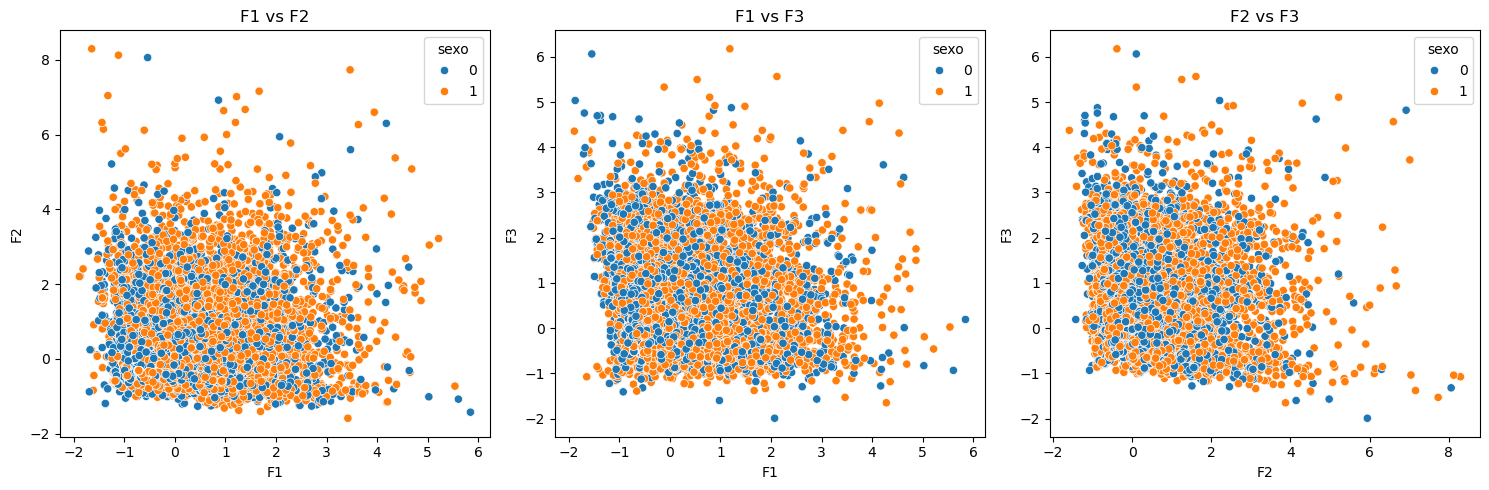

In [16]:
criterio = 'sexo'  

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.scatterplot(data=df_plot, x='F1', y='F2', hue=criterio, ax=axes[0])
axes[0].set_title('F1 vs F2')

sns.scatterplot(data=df_plot, x='F1', y='F3', hue=criterio, ax=axes[1])
axes[1].set_title('F1 vs F3')

sns.scatterplot(data=df_plot, x='F2', y='F3', hue=criterio, ax=axes[2])
axes[2].set_title('F2 vs F3')

plt.tight_layout()
plt.show()

### Por área

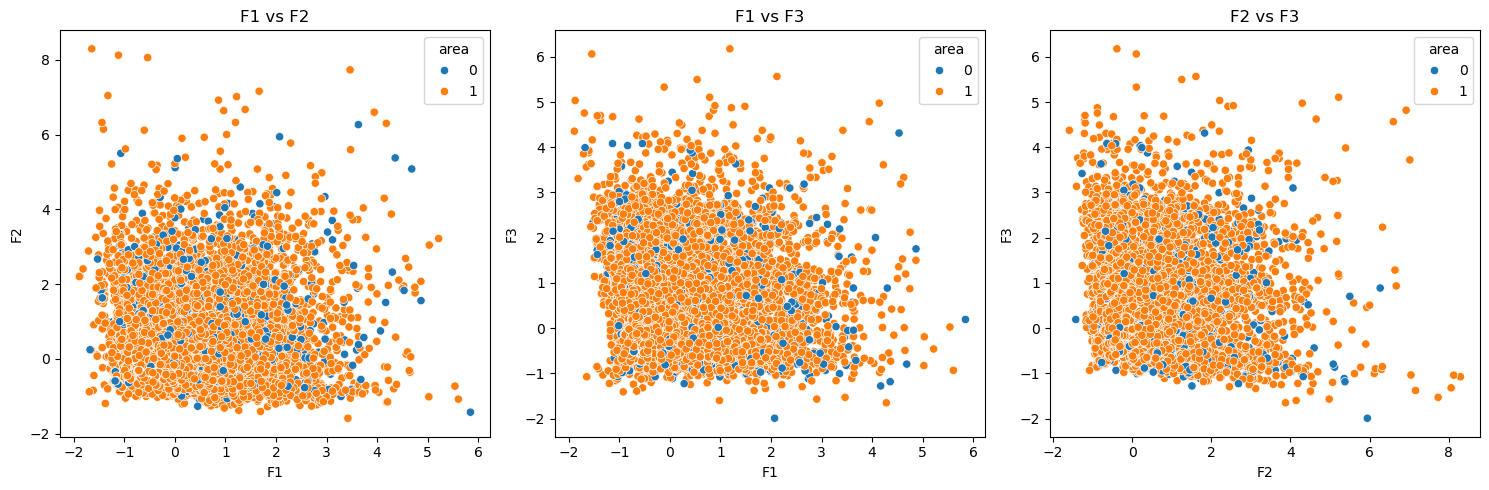

In [17]:
criterio = 'area'  

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.scatterplot(data=df_plot, x='F1', y='F2', hue=criterio, ax=axes[0])
axes[0].set_title('F1 vs F2')

sns.scatterplot(data=df_plot, x='F1', y='F3', hue=criterio, ax=axes[1])
axes[1].set_title('F1 vs F3')

sns.scatterplot(data=df_plot, x='F2', y='F3', hue=criterio, ax=axes[2])
axes[2].set_title('F2 vs F3')

plt.tight_layout()
plt.show()

### Por IMCE

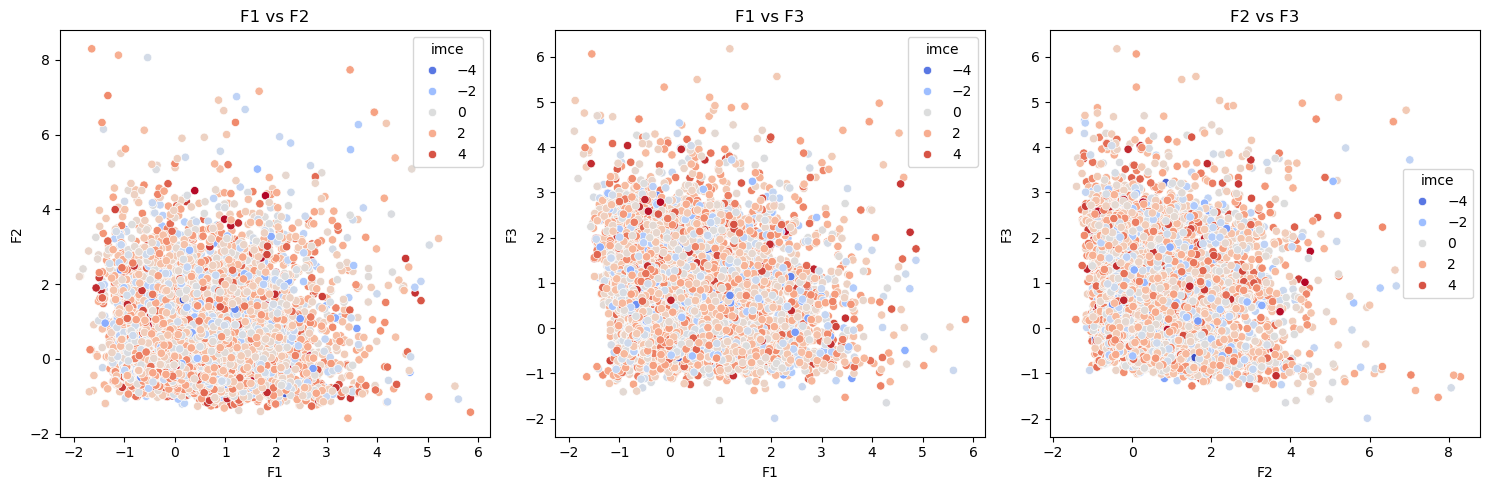

In [18]:
criterio = 'imce'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.scatterplot(data=df_plot, x='F1', y='F2', hue=criterio, palette='coolwarm', ax=axes[0])
axes[0].set_title('F1 vs F2')

sns.scatterplot(data=df_plot, x='F1', y='F3', hue=criterio, palette='coolwarm', ax=axes[1])
axes[1].set_title('F1 vs F3')

sns.scatterplot(data=df_plot, x='F2', y='F3', hue=criterio, palette='coolwarm', ax=axes[2])
axes[2].set_title('F2 vs F3')

plt.tight_layout()
plt.show()

### Por Actividad Física

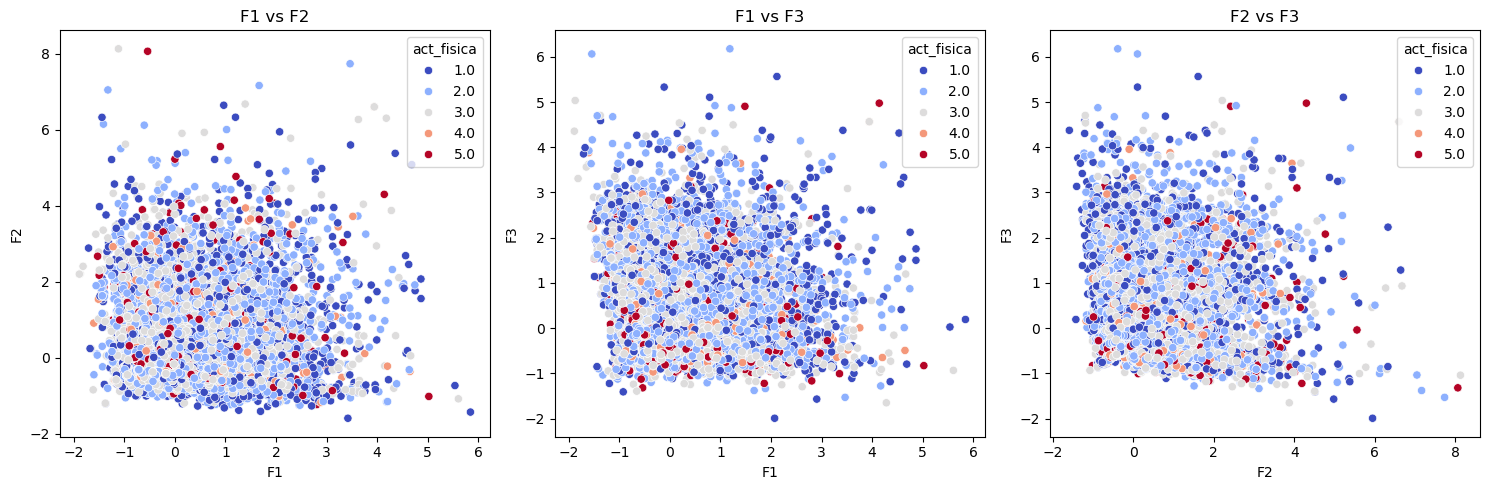

In [19]:
criterio = 'act_fisica'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.scatterplot(data=df_plot, x='F1', y='F2', hue=criterio, palette='coolwarm', ax=axes[0])
axes[0].set_title('F1 vs F2')

sns.scatterplot(data=df_plot, x='F1', y='F3', hue=criterio, palette='coolwarm', ax=axes[1])
axes[1].set_title('F1 vs F3')

sns.scatterplot(data=df_plot, x='F2', y='F3', hue=criterio, palette='coolwarm', ax=axes[2])
axes[2].set_title('F2 vs F3')

plt.tight_layout()
plt.show()

#### Respuesta: En ninguno de los indicadores y variables, se ve una diferencia significativa.

## 4. Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings). 

In [20]:
loading_df = pd.DataFrame(loadings, index=df1.columns, columns=[f'F{i+1}' for i in range(loadings.shape[1])])

# Elegimos las variables que cargan significativamente en cada factor
threshold = 0.4  # puedes ajustar este valor

factor_vars = {}
for factor in loading_df.columns:
    vars_for_factor = loading_df[loading_df[factor].abs() >= threshold].index.tolist()
    factor_vars[factor] = vars_for_factor

# Generar la sintaxis del modelo para semopy
model_lines = []
for factor, variables in factor_vars.items():
    if variables:
        line = f"{factor} =~ " + " + ".join(variables)
        model_lines.append(line)

# Unimos todo en un solo string
mod = "\n".join(model_lines)

In [21]:
model_cfa = semopy.Model(mod)
out=model_cfa.fit(df1)
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.142
Number of iterations: 42
Params: 1.335 1.233 1.092 1.261 1.793 1.603 1.778 1.027 1.155 0.160 0.055 0.057 0.063 0.165 0.096 0.100 0.601 0.204 0.448 0.716 0.245 0.201 0.160 0.154 0.376 0.476 0.284


In [22]:
factor_scores = model_cfa.predict_factors(df1)
factor_scores

,F1,F2,F3
0,0.367608,0.052642,0.007638
1,-0.337317,-0.154623,-0.299660
2,0.467175,0.450303,0.284696
3,-0.337317,-0.154623,-0.299660
4,-0.337317,-0.154623,-0.299660
...,...,...,...
31050,0.243672,0.245844,0.425197
31051,0.299561,0.134912,0.017549
31052,-0.181009,-0.139361,-0.269122
31053,-0.117039,-0.079750,0.250202


In [ ]:
#Analizar correlaciones
estimates = model_cfa.inspect()
estimates

,lval,op,rval,Estimate,Std. Err,z-value,p-value
0,sk9,~,F1,1.000000,-,-,-
1,sk10,~,F1,1.334713,0.017645,75.641962,0.0
2,sk11,~,F1,1.232807,0.013993,88.102986,0.0
3,sk12,~,F1,1.091950,0.014832,73.622089,0.0
4,sk13,~,F1,1.261417,0.017981,70.151539,0.0
5,sk1,~,F2,1.000000,-,-,-
6,sk2,~,F2,1.793157,0.021586,83.072223,0.0
7,sk3,~,F2,1.603422,0.019395,82.673817,0.0
8,sk4,~,F2,1.777960,0.020174,88.132298,0.0
9,sk5,~,F3,1.000000,-,-,-


In [45]:
print(mod)

F1 =~ sk9 + sk10 + sk11 + sk12 + sk13
F2 =~ sk1 + sk2 + sk3 + sk4
F3 =~ sk5 + sk6 + sk8


#### Respuesta: Todas las variables son significativas para el modelo, que usé filtrando los resultados de la ronda anterior. En el significado de los factores tenemos que:
#### - F1 representa su interés por conocer el mundo y expresarse a través de él.
####            - F2 representa su capacidad de gestionar emociones.
####            - F3 representa la capacidad de relacionarse con otros.

## 5. Estime un modelo de clases latentes usando imce via StepMix. Determine el numero optimo de clases (clusters) y muestre las diferencias entre clusters graficamente. Que se puede concluir de los resultados?

Fitting StepMix...


Initializations (n_init) :   0%|          | 0/1 [00:00<?, ?it/s]

Initializations (n_init) : 100%|██████████| 1/1 [00:05<00:00,  5.46s/it, max_LL=-5.39e+5, max_avg_LL=-17.4]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:09<00:00,  9.63s/it, max_LL=-5.36e+5, max_avg_LL=-17.3]


...

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [01:40<00:00, 100.76s/it, max_LL=-5.31e+5, max_avg_LL=-17.1]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [02:43<00:00, 163.81s/it, max_LL=-5.31e+5, max_avg_LL=-17.1]
/opt/anaconda3/lib/python3.12/site-packages/stepmix/stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


<Axes: >

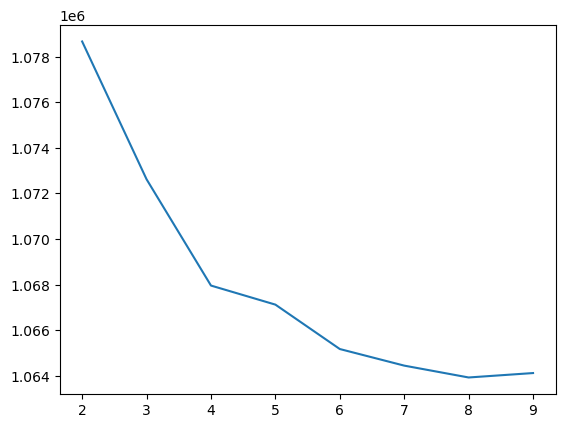

In [24]:
from stepmix.stepmix import StepMix
lat = list_dsk+['imce']
df_latente = df[lat]
# Numero optimo de clusters
K = range(2, 10)
fits = []
BIC = []

for k in K:
    # train the model for current value of k on training data
    model = StepMix(n_components=k, measurement='gaussian', verbose=0, random_state=123).fit(df_latente)
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    BIC.append(model.sabic(df_latente))

sns.lineplot(x = K, y = BIC)    

In [25]:
# Continuous StepMix Model with 3 latent classes
model = StepMix(n_components=3, measurement="gaussian", verbose=1, random_state=123)

# Fit model and predict clusters
model.fit(df_latente)
df_latente['pred']=model.predict(df_latente)

Fitting StepMix...


Initializations (n_init) :   0%|          | 0/1 [00:00<?, ?it/s]

Initializations (n_init) : 100%|██████████| 1/1 [00:10<00:00, 10.69s/it, max_LL=-5.36e+5, max_avg_LL=-17.3]


MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                
          class_no                   0       1       2
          param variable                              
          means imce            2.1840  1.0301  0.3561
                sk1             1.0705  1.5259  1.0599
                sk10            1.7662  2.9693  1.6898
                sk11            1.2814  2.3588  1.2579
                sk12            1.4133  2.4156  1.3787
                sk13            1.5805  2.9613  1.5169
                sk2             1.3194  2.1236  1.2916
                sk3             1.1932  1.8818  1.1838
                sk4             1.1732  1.9548  1.1697
                sk5             1.2162  1.8956  1.1782
                sk6             1.4380  2.2205  1.3798
                sk7             2.3865  2.7165  2.0609
                sk8             1.5043  2.4062  1.4238
                sk9             1.2370  2.1828  1.2258
    Class weights
 

/var/folders/8q/08j5pdjn55n6s7dyy49m65w00000gn/T/ipykernel_1563/1065889366.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_latente['pred']=model.predict(df_latente)


In [26]:
df_latente.groupby(['pred'])[['imce']].mean()

,imce
pred,
0,2.528531
1,1.031688
2,0.279624


In [27]:
df_latente

,sk1,sk2,sk3,sk4,sk5,sk6,sk7,sk8,sk9,sk10,sk11,sk12,sk13,imce,pred
0,1,1,1,2,1,2,2,1,2,2,2,3,2,0.75,2
1,1,1,1,1,1,1,4,1,1,1,1,1,1,0.71,2
2,2,2,3,2,1,2,3,2,2,3,2,1,3,0.27,1
3,1,1,1,1,1,1,2,1,1,1,1,1,1,2.05,0
4,1,1,1,1,1,1,3,1,1,1,1,1,1,1.05,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31050,1,3,1,2,2,1,1,3,2,2,2,1,1,1.63,2
31051,1,1,2,2,1,1,1,2,1,3,2,1,4,2.57,0
31052,1,1,1,1,1,1,1,1,1,3,1,1,1,2.12,0
31053,1,1,1,1,2,2,1,2,1,2,1,1,2,-0.43,2


<Axes: xlabel='pred', ylabel='imce'>

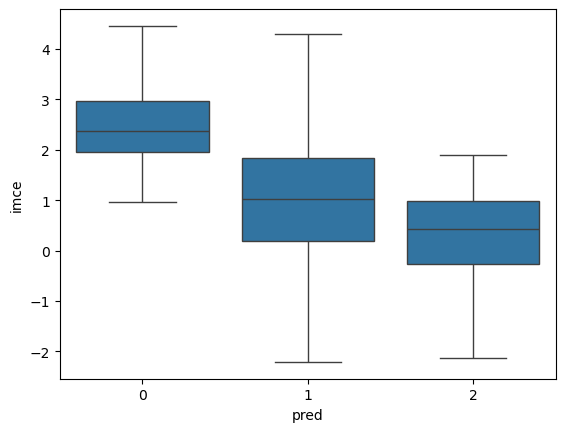

In [28]:
sns.boxplot(data=df_latente, x='pred', y='imce', showfliers=False)

#### Respuesta: Dado los parametros se ven 3 grandes clústeres, el clúster "0" de media en el imce de sobrepeso, el clúster "1" de peso promedio y el clúster "2" de peso bajo la media.

## 6. Implemente un SEM completo usando la estructura propuesta en la Pregunta 4. En particular, estime un modelo donde los factores latentes explican el imce, junto con otras variables que existen en la base de datos. Ademas utilice otras variables relevantes de la base de datos para su modelo. Las variables a incluir en el modelo final deben tener sustento teorico y el modelo final debe optimizar el ajuste a los datos, en base a los criterios vistos en clase (TLI, CLI, RMSEA). Que puede concluir en base a sus resultados?

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.341
Number of iterations: 52
Params: 1.334 1.231 1.091 1.261 1.796 1.604 1.780 1.026 1.157 -0.046 -0.296 0.232 0.133 -0.116 -0.028 -0.032 -0.014 -0.013 -0.002 0.160 0.055 0.057 0.063 0.165 0.097 1.865 0.100 0.601 0.204 0.448 0.716 0.245 0.201 0.160 0.154 0.376 0.476 0.283
    lval  op        rval  Estimate  Std. Err     z-value   p-value
0    sk9   ~          F1  1.000000         -           -         -
1   sk10   ~          F1  1.333870  0.017626    75.67699       0.0
2   sk11   ~          F1  1.231354   0.01397   88.143665       0.0
3   sk12   ~          F1  1.090943  0.014814   73.641994       0.0
4   sk13   ~          F1  1.260510  0.017961   70.181981       0.0
5    sk1   ~          F2  1.000000         -           -         -
6    sk2   ~          F2  1.795516  0.021615   83.069766       0.0
7    sk3   ~          F2  1.604009   0.01941   82.636552    

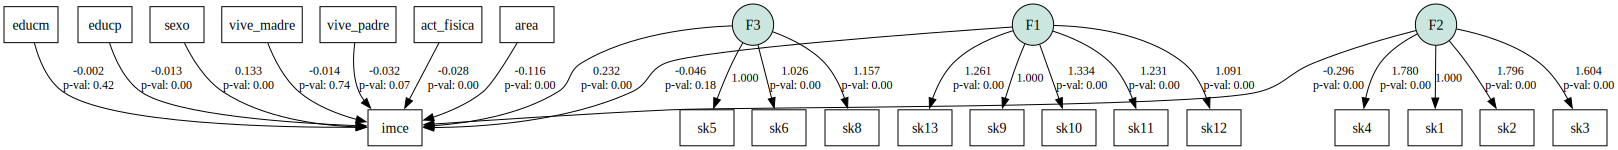

In [ ]:
mod_sem = '''
#Measurement
F1 =~ sk9 + sk10 + sk11 + sk12 + sk13            #interés por conocer el mundo y expresarse a través de él.
F2 =~ sk1 + sk2 + sk3 + sk4                     #representa su capacidad de gestionar emociones.
F3 =~ sk5 + sk6 + sk8               #representa la capacidad de relacionarse con otros.

#Structural
imce ~ F1 + F2 + F3 + sexo + area + act_fisica + vive_padre + vive_madre + educp + educm 
'''

model_sem = semopy.Model(mod_sem)
out=model_sem.fit(df)
print(out)
print(model_sem.inspect())
semopy.semplot(model_sem, "semmodel.png")

#### Respuesta: Agregando los factores antes calculados, queremos ver si el que los padres hayan sido educados, el sexo del niño, como es que la presencia de tanto padre como madre en sus vidas o el sector donde vivan influye en el físico del niño. Asi podemos ver que los 3 factores aportan al imce significativamente. Para las variables que agregué, la educación del padre, el sexo, vivir con el papá, la actividad física y el área son relevantes para el imce también. También es relevante ver que el sk5 no es relevante para el factor.

## 7. Repita el analisis de la Pregunta 6 usando para cada submuestra generada a partir de las clases latentes obtenida en la pregunta 5. Reporte diferencias entre los parametros entre los distintos grupos (si existieran). Hay alguna ganancia de estimar el modelo por grupos versus el modelo general?  

In [54]:
df_latente_unico = df_latente.drop_duplicates(subset=lat)
df_merged = df.merge(df_latente_unico, on = lat, how='left')

### Submuestra 1

In [55]:
df_merged0 = df_merged[df_merged['pred'] == 0]

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.290
Number of iterations: 49
Params: 1.680 1.456 1.356 1.268 2.249 1.782 1.791 0.870 1.031 -0.027 -0.191 0.090 0.168 -0.055 -0.017 0.006 0.033 -0.005 -0.007 0.048 0.019 0.010 0.022 0.114 0.023 0.596 0.069 0.612 0.178 0.403 0.671 0.222 0.181 0.132 0.134 0.407 0.495 0.228
    lval  op        rval  Estimate  Std. Err    z-value   p-value
0    sk9   ~          F1  1.000000         -          -         -
1   sk10   ~          F1  1.679825  0.076289  22.019106       0.0
2   sk11   ~          F1  1.456022  0.060703  23.986146       0.0
3   sk12   ~          F1  1.356113  0.061705  21.977413       0.0
4   sk13   ~          F1  1.268168  0.067388  18.819003       0.0
5    sk1   ~          F2  1.000000         -          -         -
6    sk2   ~          F2  2.248961  0.082058  27.407017       0.0
7    sk3   ~          F2  1.781812  0.067275   26.48541       0.0
8   

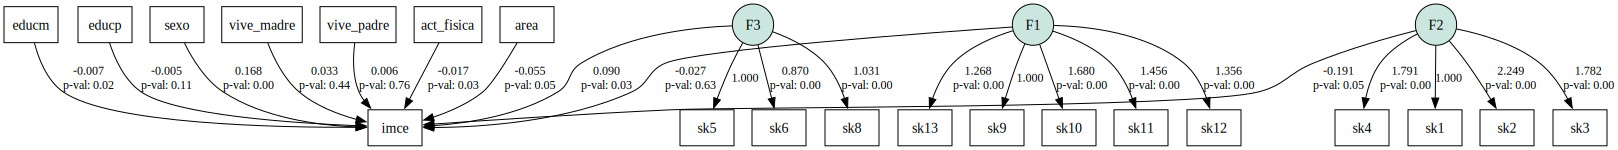

In [56]:
model_sem0 = semopy.Model(mod_sem)
out=model_sem0.fit(df_merged0)
print(out)
print(model_sem0.inspect())
semopy.semplot(model_sem0, "semmodel_m0.png")

### Submuestra 2

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.440
Number of iterations: 37
Params: 0.739 1.686 0.719 0.301 1.140 1.348 1.515 0.512 0.499 0.041 -0.027 0.090 0.107 -0.110 -0.102 -0.088 0.076 -0.008 0.010 0.174 0.203 0.030 0.129 0.621 0.008 1.596 0.403 0.875 0.341 1.010 1.281 0.523 0.465 0.414 0.124 0.743 0.878 0.838
    lval  op        rval  Estimate  Std. Err    z-value   p-value
0    sk9   ~          F1  1.000000         -          -         -
1   sk10   ~          F1  0.738789  0.061326   12.04691       0.0
2   sk11   ~          F1  1.685858  0.148734  11.334684       0.0
3   sk12   ~          F1  0.719362   0.06361  11.308862       0.0
4   sk13   ~          F1  0.301344  0.060307   4.996823  0.000001
5    sk1   ~          F2  1.000000         -          -         -
6    sk2   ~          F2  1.139987  0.048179  23.661592       0.0
7    sk3   ~          F2  1.348289  0.052729  25.570168       0.0
8    

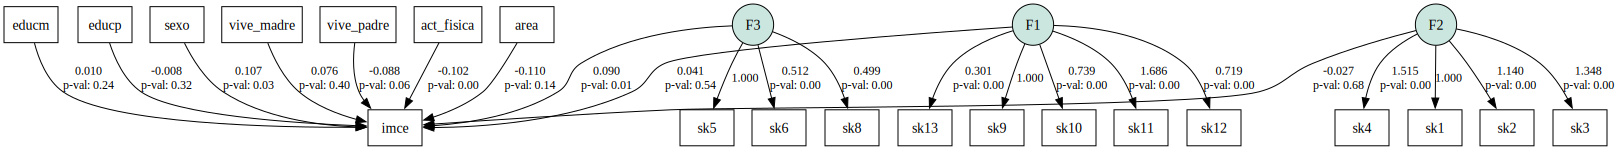

In [57]:
df_merged1 = df_merged[df_merged['pred'] == 1]
model_sem1 = semopy.Model(mod_sem)
out=model_sem1.fit(df_merged1)
print(out)
print(model_sem1.inspect())
semopy.semplot(model_sem1, "semmodel_m1.png")

### Submuestra 3

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.276
Number of iterations: 55
Params: 1.646 1.430 1.286 1.170 2.695 2.289 2.526 1.019 1.204 -0.208 -0.235 -0.194 -0.091 -0.104 0.008 0.009 -0.062 -0.005 0.004 0.046 0.012 0.008 0.015 0.079 0.022 0.875 0.059 0.542 0.158 0.372 0.610 0.209 0.161 0.124 0.113 0.315 0.404 0.218
    lval  op        rval  Estimate  Std. Err    z-value   p-value
0    sk9   ~          F1  1.000000         -          -         -
1   sk10   ~          F1  1.645976  0.050645  32.500125       0.0
2   sk11   ~          F1  1.429565  0.040524  35.277337       0.0
3   sk12   ~          F1  1.286490  0.040499  31.765633       0.0
4   sk13   ~          F1  1.170468  0.043865  26.683115       0.0
5    sk1   ~          F2  1.000000         -          -         -
6    sk2   ~          F2  2.694809  0.072181  37.334314       0.0
7    sk3   ~          F2  2.288987  0.061801  37.038033       0.0
8  

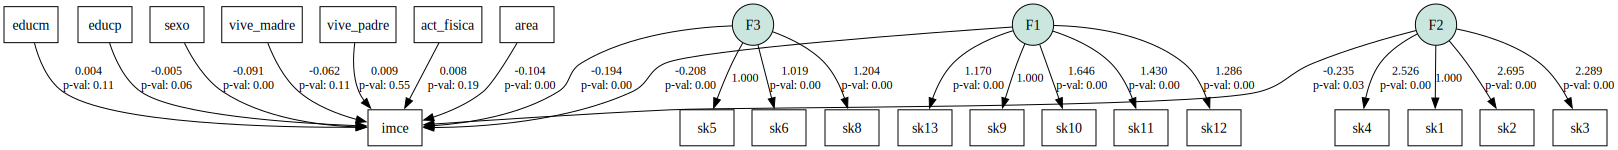

In [58]:
df_merged2 = df_merged[df_merged['pred'] == 2]
model_sem2 = semopy.Model(mod_sem)
out=model_sem2.fit(df_merged2)
print(out)
print(model_sem2.inspect())
semopy.semplot(model_sem2, "semmodel_m2.png")

#### Respuesta: En materia de factores vemos que la educación es relevante solo en la submuestra 1, el sexo es relevante en las 3 submuestras, vivir con los padres no es relevante en ninguna, el area solo es relevante en la 3ra submuestra, mientras que para esta misma hacer actividad física no lo es (al contrario de las otras dos submuestras). Para la primera submuestra ningun factor es relevante, para la segunda solo el 3 y para la ultima submuestra son los 3 importantes. SK5 no es relevante en la submuestra 1 y 2 y SK4 no es relevante en la segunda muestra. Todo esto respecto al IMCE.